<a href="https://colab.research.google.com/github/Cothilyba77/Projet_final_Force_N/blob/main/Exploration%20de%20donn%C3%A9es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. IMPORTATION DES LIBRAIRIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importation des données

In [3]:
df_malaria = pd.read_csv('/content/incidence-of-malaria.csv')
df_mortality = pd.read_csv('/content/maternal-mortality.csv')
df_prenatal = pd.read_csv('/content/share-of-mothers-receiving-at-least-one-antenatal-visit-during-pregnancy.csv')

In [5]:
df_malaria.head(5)


,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)"
0,Afghanistan,AFG,2000,84.48
1,Afghanistan,AFG,2001,83.83
2,Afghanistan,AFG,2002,83.79
3,Afghanistan,AFG,2003,70.81
4,Afghanistan,AFG,2004,39.41


In [6]:
df_combined = df_malaria.merge(df_mortality, on=['Entity', 'Year','Code'], how='outer')
df_combined = df_combined.merge(df_prenatal, on=['Entity', 'Year','Code'], how='outer')

In [7]:
df_combined.head(5)

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
0,Afghanistan,AFG,1985,NaN,1910.3416,Asia,NaN,NaN
1,Afghanistan,AFG,1986,NaN,1602.9429,Asia,NaN,NaN
2,Afghanistan,AFG,1987,NaN,1586.7214,Asia,NaN,NaN
3,Afghanistan,AFG,1988,NaN,1413.9326,Asia,NaN,NaN
4,Afghanistan,AFG,1989,NaN,1382.7299,Asia,NaN,NaN


In [8]:
df_present_entities = df_combined.dropna(subset=['Entity'])
display(df_present_entities.head())

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
0,Afghanistan,AFG,1985,NaN,1910.3416,Asia,NaN,NaN
1,Afghanistan,AFG,1986,NaN,1602.9429,Asia,NaN,NaN
2,Afghanistan,AFG,1987,NaN,1586.7214,Asia,NaN,NaN
3,Afghanistan,AFG,1988,NaN,1413.9326,Asia,NaN,NaN
4,Afghanistan,AFG,1989,NaN,1382.7299,Asia,NaN,NaN


In [9]:
unique_entities = df_combined['Entity'].unique()
display(unique_entities)

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Asia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Costa Rica', "Cote d'Ivoire", 'Croatia',
       'Cuba', 'Cyprus', 'Czechia', 'Democratic Republic of Congo',
       'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic',
       'East Asia and Pacific (WB)', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Europe', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Ge

In [10]:
west_african_countries = [
    'Benin',
    'Burkina Faso',
    'Cote d\'Ivoire',
    'Gambia',
    'Ghana',
    'Guinea',
    'Guinea-Bissau',
    'Liberia',
    'Mali',
    'Niger',
    'Nigeria',
    'Senegal',
    'Sierra Leone',
    'Togo'
]

df_westafrica = df_combined[df_combined['Entity'].isin(west_african_countries)]
display(df_westafrica.head())

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
984,Benin,BEN,1985,NaN,718.65410,Africa,NaN,NaN
985,Benin,BEN,1986,NaN,681.50360,Africa,NaN,NaN
986,Benin,BEN,1987,NaN,652.18610,Africa,NaN,NaN
987,Benin,BEN,1988,NaN,633.78674,Africa,NaN,NaN
988,Benin,BEN,1989,NaN,591.92160,Africa,NaN,NaN


In [11]:
df_westafrica.info()

<class 'pandas.core.frame.DataFrame'>
Index: 560 entries, 984 to 8791
Data columns (total 8 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               560 non-null    object 
 1   Code                                                 560 non-null    object 
 2   Year                                                 560 non-null    int64  
 3   Incidence of malaria (per 1,000 population at risk)  350 non-null    float64
 4   Maternal mortality ratio                             504 non-null    float64
 5   World region according to OWID                       504 non-null    object 
 6   Maternal mortality ratio (Annotations)               0 non-null      object 
 7   Pregnant women receiving prenatal care (%)           120 non-null    float64
dtypes: float64(3), int64(1), object(4)
memory usage: 39.4+ KB


In [ ]:
df_westafrica.isna().sum()

,0
Entity,0
Code,0
Year,0
"Incidence of malaria (per 1,000 population at risk)",210
Maternal mortality ratio,56
World region according to OWID,56
Maternal mortality ratio (Annotations),560
Pregnant women receiving prenatal care (%),440


<Axes: >

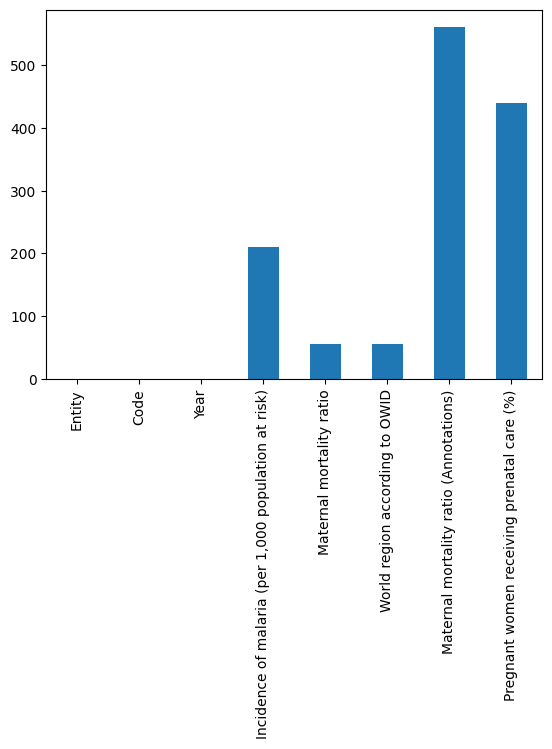

In [13]:
df_westafrica.isna().sum().plot(kind='bar')

In [14]:
missing_by_entity = df_westafrica.groupby('Entity').apply(lambda x: x.isnull().sum())
display(missing_by_entity)

/tmp/ipykernel_6358/3118465213.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_entity = df_westafrica.groupby('Entity').apply(lambda x: x.isnull().sum())


,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
Entity,,,,,,,,
Benin,0,0,0,15,4,4,40,34
Burkina Faso,0,0,0,15,4,4,40,32
Cote d'Ivoire,0,0,0,15,4,4,40,33
Gambia,0,0,0,15,4,4,40,34
Ghana,0,0,0,15,4,4,40,25
Guinea,0,0,0,15,4,4,40,31
Guinea-Bissau,0,0,0,15,4,4,40,35
Liberia,0,0,0,15,4,4,40,32
Mali,0,0,0,15,4,4,40,32


In [15]:
df_westafrica.head(560)

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
984,Benin,BEN,1985,NaN,718.65410,Africa,NaN,NaN
985,Benin,BEN,1986,NaN,681.50360,Africa,NaN,NaN
986,Benin,BEN,1987,NaN,652.18610,Africa,NaN,NaN
987,Benin,BEN,1988,NaN,633.78674,Africa,NaN,NaN
988,Benin,BEN,1989,NaN,591.92160,Africa,NaN,NaN
...,...,...,...,...,...,...,...,...
8787,Togo,TGO,2020,283.92,399.03983,Africa,NaN,NaN
8788,Togo,TGO,2021,279.51,NaN,NaN,NaN,NaN
8789,Togo,TGO,2022,278.59,NaN,NaN,NaN,NaN
8790,Togo,TGO,2023,264.80,NaN,NaN,NaN,NaN
